[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_05/05_07_ensembles_votacao_e_boosting.ipynb)

# Unidade V — Classificação e Regressão

## Ensembles por votação e boosting

**Carga estimada:** 2 horas

> **Pergunta norteadora:** quando modelos diferentes devem votar e quando novos modelos devem corrigir erros anteriores?

Bagging, estudado no notebook 05.06, é uma família de ensemble. Aqui ampliaremos a visão com votação, combinação de probabilidades e boosting.

## Objetivos de aprendizagem

- distinguir votação dura e suave;
- explicar diversidade e complementaridade;
- descrever o caráter sequencial do boosting;
- interpretar pesos de objetos e modelos no AdaBoost;
- comparar bagging e boosting;
- avaliar ensembles sob o mesmo protocolo de teste.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="colorblind")

## 1. Duas maneiras de combinar modelos

- **Paralela:** modelos são ajustados independentemente; depois votam. Bagging e votação heterogênea seguem essa ideia.
- **Sequencial:** cada modelo considera o desempenho anterior. Boosting constrói uma sequência de correções.

Um ensemble melhora quando seus componentes têm competência e cometem erros diferentes. Muitos modelos idênticos não criam nova informação.

## 2. Votação dura e votação suave

Na **votação dura**, cada modelo fornece uma classe e vence a maioria. Na **votação suave**, calculamos a média — eventualmente ponderada — das probabilidades e escolhemos a maior.

Probabilidades mal calibradas podem dominar indevidamente a votação suave. Pesos só devem ser escolhidos com validação, nunca pelo teste final.

In [2]:
votos = pd.DataFrame({
    "modelo": ["A", "B", "C"],
    "classe_prevista": [1, 1, 0],
    "P(classe=1)": [0.51, 0.55, 0.05],
})
voto_duro = votos["classe_prevista"].mode().iloc[0]
probabilidade_media = votos["P(classe=1)"].mean()
voto_suave = int(probabilidade_media >= 0.5)

display(votos)
print(f"Votação dura: classe {voto_duro}")
print(f"Probabilidade média: {probabilidade_media:.3f}; votação suave: classe {voto_suave}")

,modelo,classe_prevista,P(classe=1)
0,A,1,0.51
1,B,1,0.55
2,C,0,0.05


Votação dura: classe 1
Probabilidade média: 0.370; votação suave: classe 0


O exemplo produz decisões diferentes: dois modelos passam ligeiramente de 0,5, mas o terceiro atribui probabilidade muito baixa à classe 1. Isso não prova qual voto é melhor; mostra que a regra de agregação faz parte do modelo e deve ser avaliada.

## 3. Boosting: aprender com os erros anteriores

O AdaBoost começa com pesos iguais para os objetos. Após cada classificador:

1. mede o erro ponderado;
2. aumenta relativamente a atenção aos casos errados;
3. atribui maior peso de voto a modelos mais competentes;
4. treina o próximo modelo sobre a nova distribuição de atenção.

Para classificação binária, uma forma comum do peso do modelo é

$$\alpha_t=\frac{1}{2}\log\left(\frac{1-\varepsilon_t}{\varepsilon_t}\right).$$

Se $\varepsilon_t<0{,}5$, o voto é positivo. Erro próximo de zero gera voto forte; erro próximo de 0,5 produz pouca contribuição.

In [3]:
rodada = pd.DataFrame({
    "objeto": list("ABCDEF"),
    "classe_real": [0, 0, 0, 1, 1, 1],
    "previsão": [0, 0, 1, 0, 1, 1],
    "peso_inicial": np.repeat(1/6, 6),
})
rodada["errou"] = rodada["classe_real"] != rodada["previsão"]
erro = rodada.loc[rodada["errou"], "peso_inicial"].sum()
alpha = 0.5 * np.log((1 - erro) / erro)
fator = np.where(rodada["errou"], np.exp(alpha), np.exp(-alpha))
rodada["peso_atualizado"] = rodada["peso_inicial"] * fator
rodada["peso_atualizado"] /= rodada["peso_atualizado"].sum()

display(rodada.round(3))
print(f"Erro ponderado = {erro:.3f}; peso do modelo = {alpha:.3f}")

,objeto,classe_real,previsão,peso_inicial,errou,peso_atualizado
0,A,0,0,0.167,False,0.125
1,B,0,0,0.167,False,0.125
2,C,0,1,0.167,True,0.250
3,D,1,0,0.167,True,0.250
4,E,1,1,0.167,False,0.125
5,F,1,1,0.167,False,0.125


Erro ponderado = 0.333; peso do modelo = 0.347


## 4. Comparação controlada

Aplicaremos árvore rasa, bagging, AdaBoost e votação heterogênea à mesma divisão treino/teste. A árvore rasa é um modelo-base deliberadamente simples; boosting combina vários desses modelos fracos.

In [4]:
X, y = make_moons(n_samples=800, noise=.28, random_state=RANDOM_STATE)
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=.30, stratify=y, random_state=RANDOM_STATE
)
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(), n_estimators=100,
    max_samples=.8, n_jobs=-1, random_state=RANDOM_STATE
)
boosting = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=150, learning_rate=.5, random_state=RANDOM_STATE
)
votacao = VotingClassifier(
    estimators=[
        ("logística", make_pipeline(StandardScaler(), LogisticRegression())),
        ("knn", make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))),
        ("árvore", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)),
    ],
    voting="soft",
)
modelos = {"Árvore rasa": stump, "Bagging": bagging,
           "AdaBoost": boosting, "Votação suave": votacao}
linhas = []
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    pred = modelo.predict(X_teste)
    prob = modelo.predict_proba(X_teste)[:, 1]
    linhas.append({"modelo": nome, "acurácia": accuracy_score(y_teste, pred),
                   "F1": f1_score(y_teste, pred), "log loss": log_loss(y_teste, prob)})
resultados = pd.DataFrame(linhas)
display(resultados.round(3))

,modelo,acurácia,F1,log loss
0,Árvore rasa,0.854,0.858,0.417
1,Bagging,0.921,0.919,0.344
2,AdaBoost,0.925,0.924,0.476
3,Votação suave,0.942,0.941,0.223


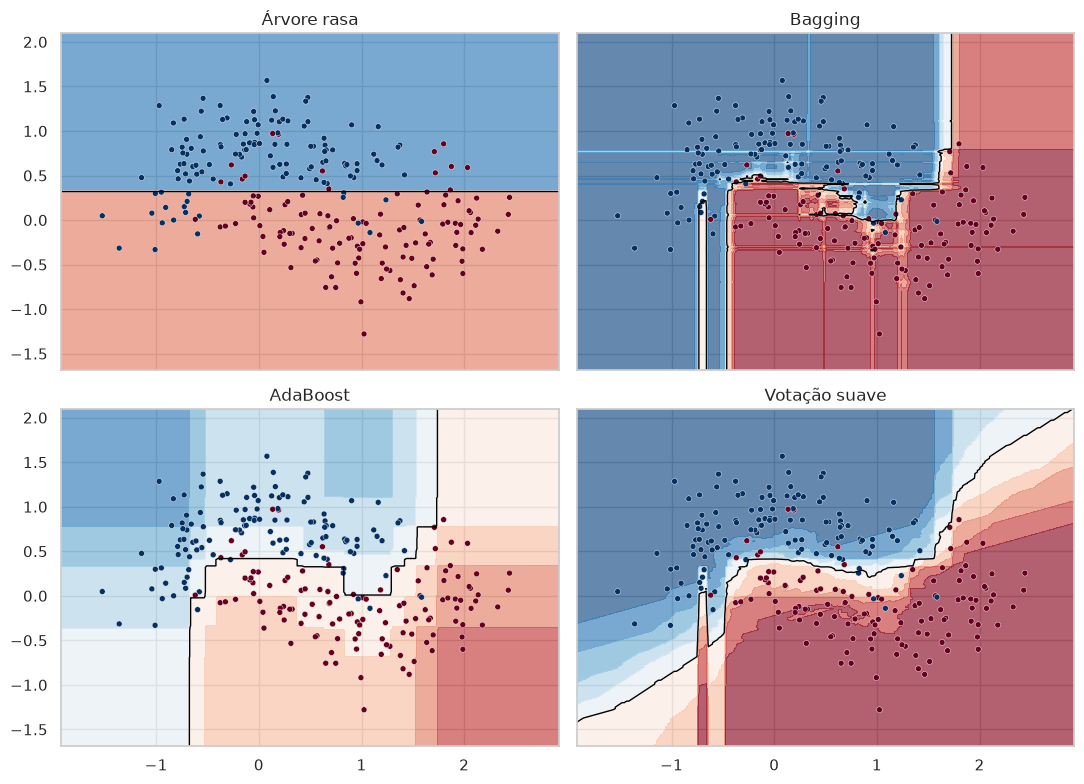

In [5]:
x1 = np.linspace(X[:, 0].min()-.4, X[:, 0].max()+.4, 220)
x2 = np.linspace(X[:, 1].min()-.4, X[:, 1].max()+.4, 220)
xx, yy = np.meshgrid(x1, x2); grade = np.c_[xx.ravel(), yy.ravel()]
fig, eixos = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)
for ax, (nome, modelo) in zip(eixos.ravel(), modelos.items()):
    p = modelo.predict_proba(grade)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=np.linspace(0,1,11), cmap="RdBu_r", alpha=.65)
    ax.contour(xx, yy, p, levels=[.5], colors="black", linewidths=1)
    ax.scatter(X_teste[:,0], X_teste[:,1], c=y_teste, cmap="RdBu_r",
               s=18, edgecolor="white", linewidth=.3)
    ax.set_title(nome)
plt.tight_layout(); plt.show()

## 5. Mais modelos nem sempre resolvem

A curva por estágios mostra o que acontece ao adicionar classificadores ao AdaBoost. O desempenho pode estabilizar ou cair: ruído e rótulos incorretos também recebem atenção. O número de modelos e a taxa de aprendizagem devem ser escolhidos dentro do treino.

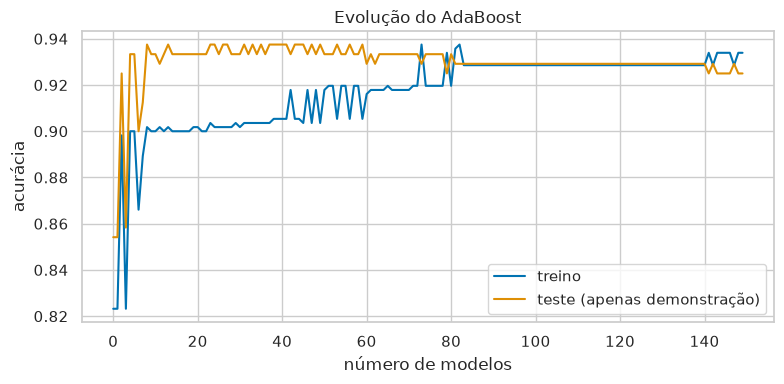

In [6]:
acuracia_treino = [
    accuracy_score(y_treino, p) for p in boosting.staged_predict(X_treino)
]
acuracia_teste = [
    accuracy_score(y_teste, p) for p in boosting.staged_predict(X_teste)
]
plt.figure(figsize=(8,4))
plt.plot(acuracia_treino, label="treino")
plt.plot(acuracia_teste, label="teste (apenas demonstração)")
plt.xlabel("número de modelos"); plt.ylabel("acurácia")
plt.title("Evolução do AdaBoost")
plt.legend(); plt.tight_layout(); plt.show()

## 6. Quando considerar cada estratégia

| Estratégia | Força | Atenção |
|---|---|---|
| Bagging | reduz instabilidade e paraleliza | pode manter viés e ser grande |
| Floresta aleatória | combina estabilidade e diversidade | perde transparência de uma árvore |
| Votação | reúne modelos com visões diferentes | depende de complementaridade e calibração |
| Boosting | corrige erros sequencialmente | pode enfatizar ruído e custa serialmente |

A escolha não deve usar apenas acurácia. Considere F1, probabilidades, custo dos erros, tempo, memória, estabilidade e necessidade de explicação.

## Atividades

### U05-NB07-V01 — Duas votações

Com classes previstas $[1,1,0]$ e probabilidades para classe 1 iguais a $[0{,}51,0{,}55,0{,}05]$, calcule votação dura e suave e explique a divergência.

### U05-NB07-E01 — Primeira rodada do AdaBoost

Se quatro objetos têm peso 0,25 e um classificador erra somente um, calcule $\varepsilon$ e $\alpha$. Explique o que ocorre à atenção relativa desse objeto.

### U05-NB07-E02 — Bagging e boosting

Compare ordem de treinamento, pesos dos modelos, tratamento dos erros anteriores, paralelização e sensibilidade a ruído.

### U05-NB07-E03 — Ensemble sem diversidade

Três modelos apresentam acurácia semelhante e erram exatamente os mesmos clientes. Avalie se a votação provavelmente ajudará e proponha duas formas responsáveis de buscar diversidade.

## Síntese

- Votação dura combina classes; votação suave combina probabilidades.
- Boosting é sequencial e concentra atenção em erros anteriores.
- Bagging reduz variância por reamostragem independente.
- Diversidade útil, calibração e avaliação preservada importam mais que quantidade de modelos.
- Ensembles melhoram previsões, mas aumentam custo e dificultam explicação.

## Referências

- HAN, J.; PEI, J.; TONG, H. *Data Mining: Concepts and Techniques*. 4. ed. Morgan Kaufmann, 2023. Seções 6.7.1 e 6.7.3.
- SCIKIT-LEARN DEVELOPERS. Documentação de VotingClassifier e AdaBoostClassifier.

Dados e figuras autorais, gerados localmente.